<strong>Factors Contributing to House Prices in the United States</strong><br>
<strong>Team Members:</strong> Brody Hughson, Cesar Fontanelli, Marris Jones, Pedro Liriano, and Jeremiah Tatum

<strong>Abstract</strong><br>
This project has been commenced with the goal of identifying the major factors contributing to home/rental prices across the United States. Additionally, this project is being conducted in the hopes of identifying where home conditions and prices are optimal for working and middle class people across the country. Factors and data considered include population density, residential permit counts by county, household median income, etc. Datasets from which these factors were analyzed include U.S. Census population datasets, Zillow Home Value Index datasets, a Residential Housing Permits by County dataset, and more. The datasets were cleaned of duplicate records, and records were primarily (or in some cases completely) composed of null fields. In some cases, dataset column names were changed to make them easier to understand. Once data cleaning had been completed, the datasets were compiled where appropriate, and analyzed to identify common statistical descriptions (e.g. min, max, mean, median) as well as the correlation between various variables. The data was grouped by city, and gross statistical outliers were grouped into their own datasets where appropriate. Once data analysis was complete, a machine learning model was trained on the dataset to better determine the relationship between factors. Finally, the findings of the project are presented with charts accompanied with explanations of the charts, and their associated findings. The study finds that none of the considered variables have a significant effect on home value.


<strong>Background</strong><br>
Many people online complain that home prices in the United States are unaffordable. In my experience, many homes that are for sale in my area are outside of my means. As such, I was interested in analyzing home prices and economic conditions across the country to identify the causes of present-day home prices, and where they are least felt.

<strong>Methodology</strong><br>
Several datasets were loaded into the document to examine their data. These datasets include the U.S. Census Bureau 2024 population sub-estimate by county, the Zillow Home Value Index (one for single family home value and another for rent), residential housing construction permits by county, ACS 5yr Housing Estimates, 30yr interest rate per year, and household median income in 2023 per state.<br><br>
Each dataset was loaded into a pandas dataframe, cleaned of records with null values, described with common statistical analysis, and visualized with relevant altair charts. Key datasets were then combined into one dataset for further analysis, only preserving records that had values for the regions in the Zillow datasets, and which had data for the years 2020-2024. An additional dataset was then created which included values for the year 2023, and includes the household median income per state. The 2023 dataset was then used to create a scatter plot matrix showing the correlation between variables in the dataset.<br><br>
Finally, the machine learning algorithms Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor were tested for fitting and predicting the data, as well as identifying the importance of variables in influencing home prices. After measuring the results of each algorithm by R2 score and mean squared error, Random Forest Regressor was selected to identify the feature importance of the variables available in the data set on home prices. The results of each algorithm test were visualized with a line chart showing the actual and predicted values.

In [1]:
#Imports
import pandas as pd
from altair import Chart, X, Y, Color, Scale
import altair as alt
import matplotlib.pyplot as plt
import numpy as np

<strong>Data Retrieval and Initial Exploratory Analysis</strong>

In [2]:
#Load data U.S. Population by county 2020-2024 source: https://www.census.gov/data/tables/time-series/demo/popest/2020s-total-cities-and-towns.html
pop_df = pd.read_csv('https://www2.census.gov/programs-surveys/popest/datasets/2020-2024/cities/totals/sub-est2024.csv', encoding='latin-1')
pop_df.head()

,SUMLEV,STATE,COUNTY,PLACE,COUSUB,CONCIT,PRIMGEO_FLAG,FUNCSTAT,NAME,STNAME,ESTIMATESBASE2020,POPESTIMATE2020,POPESTIMATE2021,POPESTIMATE2022,POPESTIMATE2023,POPESTIMATE2024
0,40,1,0,0,0,0,0,A,Alabama,Alabama,5025369,5033094,5049196,5076181,5117673,5157699
1,162,1,0,124,0,0,0,A,Abbeville city,Alabama,2349,2349,2329,2328,2337,2370
2,162,1,0,460,0,0,0,A,Adamsville city,Alabama,4393,4381,4315,4251,4204,4181
3,162,1,0,484,0,0,0,A,Addison town,Alabama,661,659,665,670,669,676
4,162,1,0,676,0,0,0,A,Akron town,Alabama,229,228,229,226,229,233


<strong>Observation</strong><br>
We can see that the above dataset contains data for various geographic levels. To avoid mixing data from several unrelated counties with the city-level data available in other datasets, this data will be narrowed down to records with a SUMLEV of 162, which refers to municipalities. Additionally, to avoid confusing city records which share a name, the city-level dataframe is further reduced to cities with a population greater than 100,000. While this approach may result in the loss of some records from the city-level home prices dataset, it effectively solves the aforementioned problem.

In [3]:
#Exploratory Analysis on Population
#Create filtered df that contains total population by city (SUMLEV = 162)
city_pop_df = pop_df[pop_df["SUMLEV"] == 162].copy()
city_pop_df = city_pop_df.reset_index(drop=True)
#Remove cities with less than 100000 population
print(city_pop_df.shape)
city_pop_df = city_pop_df[city_pop_df["POPESTIMATE2020"] > 100000].reset_index(drop=True)
print(city_pop_df.shape)
#Describe city_pop_df
city_pop_df[["POPESTIMATE2020", "POPESTIMATE2021", "POPESTIMATE2022", "POPESTIMATE2023", "POPESTIMATE2024"]].describe()

(19479, 16)
(323, 16)


,POPESTIMATE2020,POPESTIMATE2021,POPESTIMATE2022,POPESTIMATE2023,POPESTIMATE2024
count,3.230000e+02,3.230000e+02,3.230000e+02,3.230000e+02,3.230000e+02
mean,2.994445e+05,2.977475e+05,2.988574e+05,3.010314e+05,3.040163e+05
std,5.911474e+05,5.762745e+05,5.725217e+05,5.755502e+05,5.816003e+05
min,1.000650e+05,9.924300e+04,9.816400e+04,9.858800e+04,9.823000e+04
25%,1.187560e+05,1.179695e+05,1.204045e+05,1.212285e+05,1.222045e+05
50%,1.593280e+05,1.583500e+05,1.597760e+05,1.604910e+05,1.633040e+05
75%,2.672095e+05,2.705615e+05,2.743825e+05,2.761295e+05,2.775815e+05
max,8.740306e+06,8.453772e+06,8.356179e+06,8.390888e+06,8.478072e+06


In [4]:
#Trend line of population per year by quartile
#Create subdataframes for each quartile of city_pop_df
city_pop_q1_df = city_pop_df[city_pop_df["POPESTIMATE2020"] <= 1.187560e+05].reset_index(drop=True)
city_pop_q2_df = city_pop_df[(city_pop_df["POPESTIMATE2020"] <= 1.593280e+05) & (city_pop_df["POPESTIMATE2020"] > 1.187560e+05)].reset_index(drop=True)
city_pop_q3_df = city_pop_df[(city_pop_df["POPESTIMATE2020"] <= 2.672095e+05) & (city_pop_df["POPESTIMATE2020"] > 1.593280e+05)].reset_index(drop=True)
city_pop_q4_df = city_pop_df[city_pop_df["POPESTIMATE2020"] > 2.672095e+05].reset_index(drop=True)
#Create trend series of averages per year
pop_trend_q1 = city_pop_q1_df[["POPESTIMATE2020", "POPESTIMATE2021", "POPESTIMATE2022", "POPESTIMATE2023", "POPESTIMATE2024"]].mean()
pop_trend_q2 = city_pop_q2_df[["POPESTIMATE2020", "POPESTIMATE2021", "POPESTIMATE2022", "POPESTIMATE2023", "POPESTIMATE2024"]].mean()
pop_trend_q3 = city_pop_q3_df[["POPESTIMATE2020", "POPESTIMATE2021", "POPESTIMATE2022", "POPESTIMATE2023", "POPESTIMATE2024"]].mean()
pop_trend_q4 = city_pop_q4_df[["POPESTIMATE2020", "POPESTIMATE2021", "POPESTIMATE2022", "POPESTIMATE2023", "POPESTIMATE2024"]].mean()
#Combine series into trends df
pop_trends_df = pd.DataFrame({"Q1":pop_trend_q1, "Q2":pop_trend_q2, "Q3":pop_trend_q3, "Q4":pop_trend_q4})
#Set Year as index for chart
pop_trends_df_reset = pop_trends_df.reset_index().rename(columns={"index":"Year"})
#Create chart
alt.Chart(pop_trends_df_reset).transform_fold(
    ["Q1", "Q2", "Q3", "Q4"],
    as_=["Quartile", "AvgPopulation"]
).mark_line(point=True).encode(
    x="Year:O",
    y="AvgPopulation:Q",
    color="Quartile:N"
)

alt.Chart(...)

<strong>Analysis</strong><br>
We can see that the populations for cities in the first, second, and third quartiles saw little change from 2020 to 2024. However, cities in the upper quartile saw a slight decline before growing past 2020 levels by 2024. These population trends suggest that, on average, population has been constant, and thus not a significant factor in of itself.

In [5]:
# Load Single Family Home Data From Zillow
hv_df = pd.read_csv('Data/Metro_zhvi_uc_sfr_tier_0.33_0.67_sm_sa_month.csv')
hv_df = hv_df.dropna().reset_index(drop=True)
print(hv_df.shape)
hv_df.head()

(303, 317)


,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,...,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31
0,394913,1,"New York, NY",msa,NY,216204.906949,217118.726894,218037.699710,219896.351318,221811.278678,...,702182.814240,704969.033163,707107.919763,708900.805287,710150.247552,710896.834350,712302.053289,714730.852730,718376.989056,722152.928657
1,753899,2,"Los Angeles, CA",msa,CA,229297.470433,230172.549865,231311.720436,233582.033926,236045.928058,...,999743.331098,995425.637330,990670.231609,986095.146144,983311.895154,981993.638461,983107.386702,985799.648759,989828.455467,994554.776693
2,394463,3,"Chicago, IL",msa,IL,155779.960126,155931.205194,156209.724698,156902.542597,157730.488497,...,343920.881014,344749.181516,345226.838090,345740.750099,346716.042282,347812.294196,349197.912152,350501.179573,352118.031490,354044.365771
3,394692,5,"Houston, TX",msa,TX,124201.785021,124222.275651,124132.587009,124187.678168,124237.524336,...,311422.028483,310507.749997,309567.114049,308577.371747,307742.508535,307038.679976,306588.438186,306205.991455,306032.499583,306061.376066
4,395209,6,"Washington, DC",msa,VA,190554.271674,190724.956272,191018.183957,191687.549705,192690.707732,...,613647.858539,613390.166609,612066.818598,610552.119406,609282.350791,608480.941311,608399.190942,608991.010218,610130.502925,611293.161618


<strong>Observation</strong><br>
We can see that the dataset contains home price data for each month from 2000 to 2025. Since our other datasets only contain data up to 2024, and that data is aggregated by year, we will need to resize the dataset into yearly home values per city between 2020 and 2024.

In [6]:
#Exploratory analysis on SF home data
#Creat subset of SF Home Data that contains average home value per year
yearly_hv_df = hv_df[["RegionID", "RegionName"]].copy()
#Add 2020 column
yearly_hv_df["2020"] = hv_df.filter(like="2020").mean(axis=1)
#Add 2021 column
yearly_hv_df["2021"] = hv_df.filter(like="2021").mean(axis=1)
#Add 2022 column
yearly_hv_df["2022"] = hv_df.filter(like="2022").mean(axis=1)
#Add 2023 column
yearly_hv_df["2023"] = hv_df.filter(like="2023").mean(axis=1)
#Add 2024 column
yearly_hv_df["2024"] = hv_df.filter(like="2024").mean(axis=1)
#Describe single family home value dataframe
print(yearly_hv_df.shape)
yearly_hv_df[["2020", "2021", "2022", "2023", "2024"]].describe()

(303, 7)


,2020,2021,2022,2023,2024
count,303.000000,3.030000e+02,3.030000e+02,3.030000e+02,3.030000e+02
mean,237725.882405,2.763074e+05,3.162220e+05,3.233422e+05,3.367307e+05
std,148027.712157,1.742300e+05,2.031868e+05,2.008187e+05,2.094643e+05
min,72347.361015,7.900944e+04,8.256555e+04,8.160028e+04,8.117405e+04
25%,139801.111790,1.628118e+05,1.802297e+05,1.864407e+05,1.955466e+05
50%,195063.507799,2.251554e+05,2.593602e+05,2.686258e+05,2.832674e+05
75%,275449.819907,3.306017e+05,3.783997e+05,3.889072e+05,4.028104e+05
max,975942.963809,1.133728e+06,1.391799e+06,1.427432e+06,1.507342e+06


In [7]:
#Trend line of SF home prices per year by quartile
#Create subdataframes for each quartile of yearly_hv_df
yearly_hv_q1_df = yearly_hv_df[yearly_hv_df["2020"] <= 139801.111790].reset_index(drop=True)
yearly_hv_q2_df = yearly_hv_df[(yearly_hv_df["2020"] <= 195063.507799) & (yearly_hv_df["2020"] > 139801.111790)].reset_index(drop=True)
yearly_hv_q3_df = yearly_hv_df[(yearly_hv_df["2020"] <= 275449.819907) & (yearly_hv_df["2020"] > 195063.507799)].reset_index(drop=True)
yearly_hv_q4_df = yearly_hv_df[yearly_hv_df["2020"] > 275449.819907].reset_index(drop=True)
#Create trend series of averages per year
hv_trend_q1 = yearly_hv_q1_df[["2020", "2021", "2022", "2023", "2024"]].mean()
hv_trend_q2 = yearly_hv_q2_df[["2020", "2021", "2022", "2023", "2024"]].mean()
hv_trend_q3 = yearly_hv_q3_df[["2020", "2021", "2022", "2023", "2024"]].mean()
hv_trend_q4 = yearly_hv_q4_df[["2020", "2021", "2022", "2023", "2024"]].mean()
#Combine series into trends df
hv_trends_df = pd.DataFrame({"Q1":hv_trend_q1, "Q2":hv_trend_q2, "Q3":hv_trend_q3, "Q4":hv_trend_q4})
#Set Year as index for chart
hv_trends_df_reset = hv_trends_df.reset_index().rename(columns={"index":"Year"})
#Create chart
alt.Chart(hv_trends_df_reset).transform_fold(
    ["Q1", "Q2", "Q3", "Q4"],
    as_=["Quartile", "AvgHomeValue"]
).mark_line(point=True).encode(
    x="Year:O",
    y="AvgHomeValue:Q",
    color="Quartile:N"
)

alt.Chart(...)

<strong>Analysis</strong><br>
We can see that home values saw a sharp increase from 2020 to 2022, with the upper quartiles seeing the most drastic change. Since this time period coincides with the covid quarintine, the drastic change in home values could be attributed to changes in the economy and public policy. Finally, the continued upward trend after 2022 suggests that whatever factors caused home prices to increase since 2020 are still in effect, all be it to a modest extent.

In [8]:
# Load Rental Data from Zillow 
rent_df = pd.read_csv('Data/Metro_zori_uc_sfr_sm_month.csv')
rent_df = rent_df.dropna().reset_index(drop=True)
rent_df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,2015-01-31,2015-02-28,2015-03-31,2015-04-30,2015-05-31,...,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31
0,394913,1,"New York, NY",msa,NY,2051.900538,2073.674430,2091.698696,2102.985678,2104.583143,...,3419.456502,3440.434907,3475.028422,3493.461389,3499.061761,3505.398741,3498.478094,3506.189548,3520.638335,3527.294931
1,394463,3,"Chicago, IL",msa,IL,1412.925074,1419.169659,1427.120371,1439.497223,1450.368984,...,2320.172452,2335.313483,2346.684808,2355.452452,2373.809321,2378.700139,2385.748292,2378.994134,2378.676689,2375.586810
2,394514,4,"Dallas, TX",msa,TX,1362.956873,1371.226470,1381.051439,1394.360523,1406.557582,...,2301.402813,2312.824302,2316.975073,2319.425134,2316.686754,2309.203411,2307.348452,2305.694747,2302.928515,2297.098763
3,394692,5,"Houston, TX",msa,TX,1500.342979,1504.189431,1511.687962,1523.017552,1535.161535,...,2142.268237,2152.016809,2156.772453,2155.041635,2154.975617,2154.527876,2154.179611,2150.218149,2146.573017,2143.428600
4,395209,6,"Washington, DC",msa,VA,2004.611050,2018.661812,2035.216619,2046.197035,2054.206122,...,3060.815425,3070.451335,3077.083525,3080.365874,3092.832357,3098.658028,3100.453179,3085.716857,3076.398213,3066.136184


<strong>Observation</strong><br>
Similar to the home values dataset, we can see that the rent dataset contains columns for rent outside of the considered timespan, and enumerated by month. A yearly dataset is thus created to align the data with other datasets.

In [9]:
#Exploratory analysis on rental data
#Creat subset of Rental Data that contains average rent per year
yearly_rent_df = rent_df[["RegionID", "RegionName", "StateName"]].copy()
#Add 2020 column
yearly_rent_df["2020"] = rent_df.filter(like="2020").mean(axis=1)
#Add 2021 column
yearly_rent_df["2021"] = rent_df.filter(like="2021").mean(axis=1)
#Add 2022 column
yearly_rent_df["2022"] = rent_df.filter(like="2022").mean(axis=1)
#Add 2023 column
yearly_rent_df["2023"] = rent_df.filter(like="2023").mean(axis=1)
#Add 2024 column
yearly_rent_df["2024"] = rent_df.filter(like="2024").mean(axis=1)
#Describe single family home value dataframe
print(yearly_rent_df.shape)
yearly_rent_df[["2020", "2021", "2022", "2023", "2024"]].describe()

(170, 8)


,2020,2021,2022,2023,2024
count,170.000000,170.000000,170.000000,170.000000,170.000000
mean,1510.324876,1669.809247,1853.479172,1956.135796,2043.088275
std,487.498129,523.677857,578.228134,603.206092,623.103375
min,734.584587,822.005395,899.013259,939.002971,1028.309202
25%,1163.080643,1263.665985,1396.846883,1496.086591,1572.416758
50%,1439.596520,1610.549580,1800.861805,1900.300242,2004.225694
75%,1690.859386,1872.164645,2077.839333,2215.378398,2307.169579
max,3644.609486,3693.062461,3907.239043,4051.470416,4220.636867


In [10]:
#Trend line of rent per year by quartile
#Create subdataframes for each quartile of yearly_rent_df
yearly_rent_q1_df = yearly_rent_df[yearly_rent_df["2020"] <= 1163.080643].reset_index(drop=True)
yearly_rent_q2_df = yearly_rent_df[(yearly_rent_df["2020"] <= 1439.596520) & (yearly_rent_df["2020"] > 1163.080643)].reset_index(drop=True)
yearly_rent_q3_df = yearly_rent_df[(yearly_rent_df["2020"] <= 1690.859386) & (yearly_rent_df["2020"] > 1439.596520)].reset_index(drop=True)
yearly_rent_q4_df = yearly_rent_df[yearly_rent_df["2020"] > 1690.859386].reset_index(drop=True)
#Create trend series of averages per year
rent_trend_q1 = yearly_rent_q1_df[["2020", "2021", "2022", "2023", "2024"]].mean()
rent_trend_q2 = yearly_rent_q2_df[["2020", "2021", "2022", "2023", "2024"]].mean()
rent_trend_q3 = yearly_rent_q3_df[["2020", "2021", "2022", "2023", "2024"]].mean()
rent_trend_q4 = yearly_rent_q4_df[["2020", "2021", "2022", "2023", "2024"]].mean()
#Combine series into trends df
rent_trends_df = pd.DataFrame({"Q1":rent_trend_q1, "Q2":rent_trend_q2, "Q3":rent_trend_q3, "Q4":rent_trend_q4})
#Set Year as index for chart
rent_trends_df_reset = rent_trends_df.reset_index().rename(columns={"index":"Year"})
#Create chart
alt.Chart(rent_trends_df_reset).transform_fold(
    ["Q1", "Q2", "Q3", "Q4"],
    as_=["Quartile", "AvgRent"]
).mark_line(point=True).encode(
    x="Year:O",
    y="AvgRent:Q",
    color="Quartile:N"
)

alt.Chart(...)

<strong>Analysis</strong><br>
We can see that the cost of rent increased at approximately the same rate as home value. Likewise, cities in the upper quartile saw the largest change in the cost of rent. Combined, the home value and rent datasets suggest that factors contributing to the rise in home/rent prices were present nationwide, but were most felt in the largest cities.

In [11]:
#Load Residential Construction Permits
permits_df = pd.read_csv('Data/Residential_Construction_Permits_by_County_5026727375813176131.csv')
permits_df.head()

,OBJECTID,GEOID,STATE,COUNTY,NAME,STUSAB,STATE_NAME,ALL_PERMITS_1980,SINGLE_FAMILY_PERMITS_1980,ALL_MULTIFAMILY_PERMITS_1980,...,MULTIFAMILY_PERMITS_3_4_UNITS_2021,MULTIFAMILY_PERMITS_5_OR_MORE_UNITS_2021,ALL_PERMITS_2022,SINGLE_FAMILY_PERMITS_2022,ALL_MULTIFAMILY_PERMITS_2022,MULTIFAMILY_PERMITS_2_UNITS_2022,MULTIFAMILY_PERMITS_3_4_UNIT_2022,MULTIFAMILY_PERMITS_5_OR_MORE_2022,Shape__Area,Shape__Length
0,1,53021,53,21,Franklin,WA,Washington,185.0,81.0,104.0,...,0,5,644.0,423.0,221.0,16.0,4.0,201.0,6.923130e+09,4.260543e+05
1,2,4017,4,17,Navajo,AZ,Arizona,563.0,511.0,52.0,...,8,0,580.0,568.0,12.0,8.0,4.0,0.0,3.892301e+10,1.146737e+06
2,3,49051,49,51,Wasatch,UT,Utah,106.0,104.0,2.0,...,0,277,1009.0,991.0,18.0,0.0,6.0,12.0,5.381082e+09,4.365787e+05
3,4,49033,49,33,Rich,UT,Utah,48.0,48.0,NaN,...,0,0,71.0,71.0,0.0,0.0,0.0,0.0,5.040539e+09,3.993842e+05
4,5,49043,49,43,Summit,UT,Utah,525.0,294.0,231.0,...,30,123,560.0,470.0,90.0,0.0,0.0,90.0,8.532140e+09,6.285718e+05


<strong>Observation</strong><br>
Seeing as the dataset contains references to which state the county belongs to, the data is most useful if grouped by state. Moreover, because the dataset only contains data up to 2022, it cannot be combined with the rest of the data without forgoing data from 2023 and 2024, which would make the findings of this study less relevant to the present day. Instead, the dataset will be reduced to the permits granted from 2018 to 2022 to consider the trends in the number of permits being granted per state in a similar five-year timespan.

In [12]:
#Exploratory Data Analysis on Permits dataset
#Create subset of dataframe contains columns for single family permits from 2018-2022
recent_permits_df = permits_df[["COUNTY", "NAME", "STUSAB", "STATE_NAME", "SINGLE_FAMILY_PERMITS_2018", "SINGLE_FAMILY_PERMITS_2019", "SINGLE_FAMILY_PERMITS_2020", "SINGLE_FAMILY_PERMITS_2021", "SINGLE_FAMILY_PERMITS_2022"]].copy()
recent_permits_df = recent_permits_df.reset_index(drop=True)
#Remove records with null values
recent_permits_df = recent_permits_df.dropna().reset_index(drop=True)
#Describe recent permits df
recent_permits_df[["SINGLE_FAMILY_PERMITS_2020", "SINGLE_FAMILY_PERMITS_2021", "SINGLE_FAMILY_PERMITS_2022"]].describe()

,SINGLE_FAMILY_PERMITS_2020,SINGLE_FAMILY_PERMITS_2021,SINGLE_FAMILY_PERMITS_2022
count,2550.000000,2550.000000,2550.000000
mean,383.678431,436.662745,381.915686
std,1158.734331,1291.600433,1099.125108
min,1.000000,0.000000,0.000000
25%,18.000000,20.000000,20.000000
50%,71.000000,78.000000,75.000000
75%,242.750000,287.750000,260.000000
max,25526.000000,26069.000000,20608.000000


In [13]:
#Trend line of permits per year by quartile
#Create subdataframes for each quartile of recent_permits_df
permits_q1_df = recent_permits_df[recent_permits_df["SINGLE_FAMILY_PERMITS_2020"] <= 15.000000].reset_index(drop=True)
permits_q2_df = recent_permits_df[(recent_permits_df["SINGLE_FAMILY_PERMITS_2020"] <= 64.000000) & (recent_permits_df["SINGLE_FAMILY_PERMITS_2020"] > 15.000000)].reset_index(drop=True)
permits_q3_df = recent_permits_df[(recent_permits_df["SINGLE_FAMILY_PERMITS_2020"] <= 227.000000) & (recent_permits_df["SINGLE_FAMILY_PERMITS_2020"] > 64.000000)].reset_index(drop=True)
permits_q4_df = recent_permits_df[recent_permits_df["SINGLE_FAMILY_PERMITS_2020"] > 227.000000].reset_index(drop=True)
#Create trend series of averages per year
permits_trend_q1 = permits_q1_df[["SINGLE_FAMILY_PERMITS_2018","SINGLE_FAMILY_PERMITS_2019","SINGLE_FAMILY_PERMITS_2020", "SINGLE_FAMILY_PERMITS_2021", "SINGLE_FAMILY_PERMITS_2022"]].mean()
permits_trend_q2 = permits_q2_df[["SINGLE_FAMILY_PERMITS_2018","SINGLE_FAMILY_PERMITS_2019","SINGLE_FAMILY_PERMITS_2020", "SINGLE_FAMILY_PERMITS_2021", "SINGLE_FAMILY_PERMITS_2022"]].mean()
permits_trend_q3 = permits_q3_df[["SINGLE_FAMILY_PERMITS_2018","SINGLE_FAMILY_PERMITS_2019","SINGLE_FAMILY_PERMITS_2020", "SINGLE_FAMILY_PERMITS_2021", "SINGLE_FAMILY_PERMITS_2022"]].mean()
permits_trend_q4 = permits_q4_df[["SINGLE_FAMILY_PERMITS_2018","SINGLE_FAMILY_PERMITS_2019","SINGLE_FAMILY_PERMITS_2020", "SINGLE_FAMILY_PERMITS_2021", "SINGLE_FAMILY_PERMITS_2022"]].mean()
#Combine series into trends df
permit_trends_df = pd.DataFrame({"Q1":permits_trend_q1, "Q2":permits_trend_q2, "Q3":permits_trend_q3, "Q4":permits_trend_q4})
#Set Year as index for chart
permit_trends_df_reset = permit_trends_df.reset_index().rename(columns={"index":"Year"})
#Create chart
alt.Chart(permit_trends_df_reset).transform_fold(
    ["Q1", "Q2", "Q3", "Q4"],
    as_=["Quartile", "AvgPermits"]
).mark_line(point=True).encode(
    x="Year:O",
    y="AvgPermits:Q",
    color="Quartile:N"
)

alt.Chart(...)

<strong>Analysis</strong><br>
We can see that for all but the upper quartile, the number of single family housing permits that were granted between 2018 and 2022 was below 200. As for the upper quartile, we see a drastic increase in the number of permits being granted between 2019 and 2021 before sharply descreasing in 2022. If we were to suppose that a lack of housing supply has been contributing to the rise in home/rent prices in recent years, then we would expect the trend shown in this chart to result in a smaller delta in home/rent prices for the upper quartile of cities (since a rise in supply would necessarily result in a decrease in price). Unfortunately, the trends in the previous datasets show that this is not the case.<br>
However, it is likely that the states and cities included in the observed datasets were not grouped into the same quartiles. Therefore, this chart offers no insight into how the number of permits granted per state affected the cost of housing units in those states. That being said, the chart does show that for all but the upper quartile of states, the number of single family housing permits being granted per year was consistent, indicating steady growth alongside the gradual increase in population size.

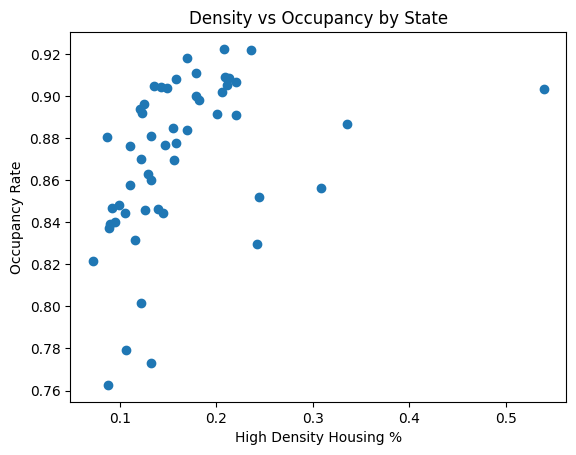

In [14]:
#Load Housing Characteristics data; Code by Jeremiah Tatum
acs = pd.read_csv("Data/ACS_5YR_Housing_Estimate_Data_by_State_-5633158829445399210.csv")
#Keep unaltered copy
house_char_df = acs.copy()
acs.columns.tolist()

#Rename Columns to make the human readable
acs = acs.rename(columns={

# --- Geography ---
"NAME": "State",

# --- Occupancy Status (B25002) ---
"B25002EST1": "Total_Housing_Units",
"B25002EST2": "Occupied_Units",
"B25002EST2_PCT": "Occupied_Units_Pct",
"B25002EST3": "Vacant_Units",
"B25002EST3_PCT": "Vacant_Units_Pct",

# --- Household Size (Owner) ---
"B25009EST2": "Owner_1Person",
"B25009EST3": "Owner_2Person",
"B25009EST4": "Owner_3Person",
"B25009EST5": "Owner_4Person",
"B25009EST6": "Owner_5Person",
"B25009EST7": "Owner_6PlusPerson",

# --- Household Size (Renter) ---
"B25009EST10": "Renter_1Person",
"B25009EST11": "Renter_2Person",
"B25009EST12": "Renter_3Person",
"B25009EST13": "Renter_4Person",
"B25009EST14": "Renter_5Person",
"B25009EST15": "Renter_6PlusPerson",

# --- Structure Type (B25024) ---
"B25024EST2": "Single_Detached",
"B25024EST3": "Single_Attached",
"B25024_2TO4": "Units_2to4",
"B25024_5TO19": "Units_5to19",
"B25024_20PLUS": "Units_20Plus",

# --- Bedrooms ---
"B25041EST2": "One_Bedroom",
"B25041EST3": "Two_Bedroom",
"B25041EST4": "ThreePlus_Bedroom",

# --- Rent Distribution ---
"B25056_500MINUS": "Rent_Under_500",
"B25056_500TO599": "Rent_500to599",
"B25056_600TO699": "Rent_600to699",
"B25056_700TO799": "Rent_700to799",

# --- Mortgage Status ---
"B25097EST1": "Total_Mortgaged",
"B25097EST2": "With_Mortgage",
"B25097EST3": "No_Mortgage"
})

#Keep Only Analytical Variables
acs = acs[[
"State",
"Total_Housing_Units",
"Occupied_Units",
"Vacant_Units",
"Single_Detached",
"Single_Attached",
"Units_2to4",
"Units_5to19",
"Units_20Plus",
"One_Bedroom",
"Two_Bedroom",
"ThreePlus_Bedroom",
"With_Mortgage",
"No_Mortgage"
]]

#Convert to numeric
for col in acs.columns[1:]:
    acs[col] = pd.to_numeric(acs[col], errors='coerce')

#Occupancy Rate
acs["Occupancy_Rate"] = acs["Occupied_Units"] / acs["Total_Housing_Units"]

#Vacancy Rate
acs["Vacancy_Rate"] = acs["Vacant_Units"] / acs["Total_Housing_Units"]

#High Density Housing Percentage
acs["High_Density_Pct"] = (
acs["Units_5to19"] + acs["Units_20Plus"]
) / acs["Total_Housing_Units"]

#Mortgage Rate
acs["Mortgage_Rate"] = acs["With_Mortgage"] / (
acs["With_Mortgage"] + acs["No_Mortgage"]
)

#Exploratory Analysis

#Summary Statistics
acs.describe()

#Missing Values
acs.isnull().sum()

#Correlation Matrix
acs.select_dtypes(include=['number']).corr()

#Visualization
plt.scatter(acs["High_Density_Pct"], acs["Occupancy_Rate"])
plt.xlabel("High Density Housing %")
plt.ylabel("Occupancy Rate")
plt.title("Density vs Occupancy by State")
plt.show()

<strong>Analysis</strong><br>
We can see that the states with a higher percentage of high density housing units (e.g. apartments) generaly saw a higher rate of occupancy among their population. We might then conclude that high density housing provides an ample supply of affordable housing. However, we see in cases such as New York City (33.57%) and Washington D.C. (53.89%) that the cost of home and rent is notably high despite the abundance of high density housing. Therefore, while we might conclude from this chart that high density housing helps to provide housing which is affordable for the people in a given state, it does not contribute to a descrease in home value or the cost of rent.

In [15]:
#Load 30yr Interest Rates
intRates_df = pd.read_csv('https://fred.stlouisfed.org/graph/fredgraph.csv?bgcolor=%23ebf3fb&chart_type=line&drp=0&fo=open%20sans&graph_bgcolor=%23ffffff&height=450&mode=fred&recession_bars=on&txtcolor=%23444444&ts=12&tts=12&width=1320&nt=0&thu=0&trc=0&show_legend=yes&show_axis_titles=yes&show_tooltip=yes&id=MORTGAGE30US&scale=left&cosd=1971-04-02&coed=2026-02-12&line_color=%230073e6&link_values=false&line_style=solid&mark_type=none&mw=3&lw=3&ost=-99999&oet=99999&mma=0&fml=a&fq=Weekly%2C%20Ending%20Thursday&fam=avg&fgst=lin&fgsnd=2020-02-01&line_index=1&transformation=lin&vintage_date=2026-02-14&revision_date=2026-02-14&nd=1971-04-02')
intRates_df.head()

,observation_date,MORTGAGE30US
0,1971-04-02,7.33
1,1971-04-09,7.31
2,1971-04-16,7.31
3,1971-04-23,7.31
4,1971-04-30,7.29


<strong>Observation</strong><br>
Since the data is records by week, it will need to be aggregated by year for analysis

In [16]:
#Exploratory Data Analysis on Interest Rates
#Creat subset of Interest Rates that contains average interest rate per year
yearly_intRate_df = intRates_df.copy()
#Add year column for aggregation
yearly_intRate_df["observation_date"] = pd.to_datetime(yearly_intRate_df["observation_date"])
yearly_intRate_df["Year"] = yearly_intRate_df["observation_date"].dt.year
#Group by year
yearly_intRate_df = yearly_intRate_df.groupby("Year")["MORTGAGE30US"].mean().reset_index()
yearly_intRate_df.rename(columns={"MORTGAGE30US":"Avg30yrInterest_Rate"}, inplace=True)
#Reduce to 2020-2024
yearly_intRate_df = yearly_intRate_df[(yearly_intRate_df["Year"] >= 2020) & (yearly_intRate_df["Year"] < 2025)].reset_index(drop=True)
#Describe yearly interest rate dataframe
yearly_intRate_df[["Avg30yrInterest_Rate"]].describe()

,Avg30yrInterest_Rate
count,5.000000
mean,4.988263
std,1.876235
min,2.957692
25%,3.111698
50%,5.344038
75%,6.721154
max,6.806731


In [17]:
#Create trend line chart
alt.Chart(yearly_intRate_df).mark_line(point=True).encode(x="Year:O", y="Avg30yrInterest_Rate:Q")

alt.Chart(...)

<strong>Analysis</strong><br>
We can see that the interest rate for 30-year loans slightly decreased from 2020 to 20221 before spiking to ~6.8% in 2023. Considering the home value dataset, we see that average home values saw a significant increase from 2020 to 2022 before settling into a modest rate of increase by 2023. Based on the trend lines in both datasets, it could be speculated that the rise in the 30-year interest rate was a reaction to one or more factors which caused the home value price to increase, resulting in a reduction in the rate of increase in home value costs, but not sufficient to reverse it.

In [18]:
#Load median household income dataset
income_df = pd.read_csv('Data/Household Median Income in States of United States (2023).csv')
#Reduce to relevant columns
income_df = income_df[["Entity properties isoCode","Variable observation value"]]
#Create state column from EPIC column
income_df["State_Abbrev"] = income_df["Entity properties isoCode"].str[-2:]
#Reorder columns and remove EPIC column
income_df = income_df[["State_Abbrev", "Variable observation value"]]
#Rename VOV column to HD_MED_INC
income_df = income_df.rename(columns={"Variable observation value":"HD_MED_INC"})
income_df.head()

,State_Abbrev,HD_MED_INC
0,AL,62027
1,AK,89336
2,AZ,76872
3,AR,58773
4,CA,96334


In [19]:
#Histogram for median income
alt.Chart(income_df).mark_bar().encode(x=alt.X('HD_MED_INC',bin=True), y='count()')

alt.Chart(...)

<strong>Analysis</strong><br>
We can see that most states have a median household income in the range 60,000 to 100,000. This would suggest that (without consideration for other expenses) most households can afford some form of housing in their state.

<strong>Inter-Tabular Exploratory Data Analysis</strong>

In [20]:
#Key table to link state name abbreviation to full name
state_name_key_df = house_char_df[["STUSAB", "NAME"]].copy()
state_name_key_df = state_name_key_df.reset_index(drop=True)
state_name_key_df.head()

,STUSAB,NAME
0,IL,Illinois
1,IN,Indiana
2,KS,Kansas
3,KY,Kentucky
4,LA,Louisiana


In [21]:
#Dataframe to combine gathered data by city
#Add zillow single-family home prices
combined_df = yearly_hv_df[['RegionName', '2020', '2021', '2022', '2023', '2024']].copy()
print("Size after copying home value: ", combined_df.shape)
#Convert to long format (City column, Year column, Price column)
combined_df = combined_df.melt(id_vars="RegionName", var_name="Year", value_name="HomePrice")
print("Size after converting to long: ", combined_df.shape)
#Convert year to datatime object
combined_df["Year"] = pd.to_datetime(combined_df['Year']).dt.year

#Add rental data
#Copy rental data into temp dataframe
rent_temp = yearly_rent_df[['RegionName', '2020', '2021', '2022', '2023', '2024']].copy()
#Convert to long format (City column, Year column, Price column)
rent_temp = rent_temp.melt(id_vars="RegionName", var_name="Year", value_name="Rent")
#Convert year to datatime object
rent_temp["Year"] = pd.to_datetime(rent_temp['Year']).dt.year
combined_df = combined_df.merge(rent_temp, on=["RegionName","Year"])
print("Size after adding rent: ", combined_df.shape)

#Add average yearly interest rate
combined_df = combined_df.merge(yearly_intRate_df, on="Year")
print("Size after adding interest rate: ", combined_df.shape)

#Split combined_df RegionName into City and State columns
combined_df[['City','State_Abbrev']] = combined_df['RegionName'].str.split(",", expand=True)
#Remove white spaces
combined_df['City'] = combined_df['City'].str.strip()
combined_df['State_Abbrev'] = combined_df['State_Abbrev'].str.strip()
#Add state full name
combined_df = pd.merge(combined_df, state_name_key_df, left_on="State_Abbrev", right_on="STUSAB")
#Remove STUSAB column from merged dataframe
combined_df = combined_df.drop(columns="STUSAB")
#Rename NAME to State
combined_df = combined_df.rename(columns={"NAME":"State"})
#Reorganize combined_df
combined_df = combined_df[['RegionName','City','State_Abbrev','State','Year','HomePrice','Rent','Avg30yrInterest_Rate']]
print("Size after adding City, State_Abbrev, State: ", combined_df.shape)

#Add population
pop_temp = city_pop_df.copy()
#Reduce to relevant columns
pop_temp = pop_temp.drop(columns=['SUMLEV','STATE','COUNTY','PLACE','COUSUB','CONCIT','PRIMGEO_FLAG','FUNCSTAT','ESTIMATESBASE2020'])
#Rename columns to year
pop_temp = pop_temp.rename(columns={"POPESTIMATE2020":"2020","POPESTIMATE2021":"2021","POPESTIMATE2022":"2022","POPESTIMATE2023":"2023","POPESTIMATE2024":"2024"})
#Convert to long format
pop_temp = pop_temp.melt(id_vars=['NAME','STNAME'], var_name="Year", value_name="Est_Population")
#Remove 'city' from city names
pop_temp['NAME'] = pop_temp['NAME'].str.replace(' city','',regex=False)
#Convert year to datatime object
pop_temp["Year"] = pd.to_datetime(pop_temp['Year']).dt.year
#Merge
combined_df = pd.merge(combined_df, pop_temp, left_on=['City','State','Year'], right_on=['NAME','STNAME','Year'])
#Remove NAME and STNAME
combined_df = combined_df.drop(columns=['NAME','STNAME'])
print("Size after adding population: ", combined_df.shape)

#Add ACS Occupancy Rate, Vacancy Rate, High_Density_Pct, Total Housing Units, and Mortgage Rate
acs_temp = acs[['State','Occupancy_Rate','Vacancy_Rate','High_Density_Pct','Mortgage_Rate', 'Total_Housing_Units']].copy()
#Merge on state
combined_df = combined_df.merge(acs_temp,on="State")
print("Size after adding Occupany Rate, Vacancy Rate, etc.: ", combined_df.shape)

#Add column for population per housing units in state (POP_STHU)
combined_df['POP_STHU'] = combined_df['Est_Population'] / combined_df['Total_Housing_Units']

#Show head
combined_df.head()

Size after copying home value:  (303, 6)
Size after converting to long:  (1515, 3)
Size after adding rent:  (590, 4)
Size after adding interest rate:  (590, 5)
Size after adding City, State_Abbrev, State:  (590, 8)
Size after adding population:  (435, 9)
Size after adding Occupany Rate, Vacancy Rate, etc.:  (435, 14)


,RegionName,City,State_Abbrev,State,Year,HomePrice,Rent,Avg30yrInterest_Rate,Est_Population,Occupancy_Rate,Vacancy_Rate,High_Density_Pct,Mortgage_Rate,Total_Housing_Units,POP_STHU
0,"New York, NY",New York,NY,New York,2020,507475.582817,2508.949018,3.111698,8740306,0.886913,0.113087,0.335737,0.540239,8362971,1.045120
1,"Chicago, IL",Chicago,IL,Illinois,2020,248213.325786,1664.589329,3.111698,2745196,0.908936,0.091064,0.209165,0.554309,5373385,0.510888
2,"Houston, TX",Houston,TX,Texas,2020,231235.318154,1681.158918,3.111698,2298945,0.891397,0.108603,0.200394,0.589344,11112975,0.206870
3,"Washington, DC",Washington,DC,District of Columbia,2020,470273.997269,2331.985489,3.111698,670917,0.903240,0.096760,0.538964,0.513725,319192,2.101923
4,"Philadelphia, PA",Philadelphia,PA,Pennsylvania,2020,262609.376620,1555.485418,3.111698,1600788,0.893802,0.106198,0.121077,0.555012,5713345,0.280184


<strong>Observation</strong><br>
The combined dataset includes data on home price per city, rent per city, interest rate per year, estimated population per city, occupancy rate per state, vacancy rate per state, high density housing percentage per state, mortgage rate per state, total housing units per state, and population per state housing units per city (used as an approximation for population density). The data is grouped in long format, with each city having a record for each year from 2020 to 2024.<br><br>
This dataset will be used to create a subdataframe containing 2023 records, which will be used to graph the correlation between various variables in the dataset. The combined dataset will also be used to train and test machine learning algorithms to better understand the importance of various variables on home price.

In [22]:
#Exploratory Data Analysis on combined_df
combined_df.describe()

,Year,HomePrice,Rent,Avg30yrInterest_Rate,Est_Population,Occupancy_Rate,Vacancy_Rate,High_Density_Pct,Mortgage_Rate,Total_Housing_Units,POP_STHU
count,435.000000,4.350000e+02,435.000000,435.000000,4.350000e+02,435.000000,435.000000,435.000000,435.000000,4.350000e+02,435.000000
mean,2022.000000,3.678210e+05,1924.351929,4.988263,5.417365e+05,0.886130,0.113870,0.187299,0.546849,5.853054e+06,0.152287
std,1.415842,1.861614e+05,641.005248,1.680087,9.640502e+05,0.030037,0.030037,0.065984,0.020659,4.390487e+06,0.262761
min,2020.000000,1.227595e+05,768.752275,2.957692,1.043160e+05,0.829434,0.077574,0.105181,0.501266,3.191920e+05,0.008676
25%,2021.000000,2.366097e+05,1439.596520,3.111698,1.901730e+05,0.863071,0.091064,0.132526,0.531888,2.361372e+06,0.036401
50%,2022.000000,3.138799e+05,1812.247129,5.344038,3.010390e+05,0.891397,0.108603,0.179111,0.547035,4.611913e+06,0.086376
75%,2023.000000,4.397963e+05,2267.646488,6.721154,5.694670e+05,0.908936,0.136929,0.235743,0.558110,9.562324e+06,0.181309
max,2024.000000,1.245513e+06,3868.584467,6.806731,8.740306e+06,0.922426,0.170566,0.538964,0.589344,1.421094e+07,2.200086


In [23]:
#Dataframe for 2023
combined_2023 = combined_df[combined_df['Year'] == 2023].copy()
#Add median income data to 2023 dataset
combined_2023 = combined_2023.merge(income_df, on="State_Abbrev")
#combined_2024 = combined_df[combined_df['Year'] == 2024].copy()
print(combined_2023.head())
#Scatter plot matrix to graph the correlation between variables in combined_df
alt.Chart(combined_2023).mark_circle().encode(
    alt.X(alt.repeat("column"), type='quantitative'),
    alt.Y(alt.repeat("row"), type='quantitative'),
    color='RegionName:N'
).properties(
    width=150,
    height=150
).repeat(
    row=['HomePrice','Rent','Avg30yrInterest_Rate','Est_Population','Occupancy_Rate','Vacancy_Rate','High_Density_Pct','Mortgage_Rate','Total_Housing_Units','POP_STHU','HD_MED_INC'],
    column=['HomePrice','Rent','Avg30yrInterest_Rate','Est_Population','Occupancy_Rate','Vacancy_Rate','High_Density_Pct','Mortgage_Rate','Total_Housing_Units','POP_STHU','HD_MED_INC']
).interactive()

         RegionName          City State_Abbrev                 State  Year  \
0      New York, NY      New York           NY              New York  2023   
1       Chicago, IL       Chicago           IL              Illinois  2023   
2       Houston, TX       Houston           TX                 Texas  2023   
3    Washington, DC    Washington           DC  District of Columbia  2023   
4  Philadelphia, PA  Philadelphia           PA          Pennsylvania  2023   

       HomePrice         Rent  Avg30yrInterest_Rate  Est_Population  \
0  634307.114784  3165.635933              6.806731         8390888   
1  312660.406888  2076.799713              6.806731         2699144   
2  309995.585013  2038.008014              6.806731         2346908   
3  574252.577488  2801.255976              6.806731          687324   
4  343360.538910  1929.206451              6.806731         1563349   

   Occupancy_Rate  Vacancy_Rate  High_Density_Pct  Mortgage_Rate  \
0        0.886913      0.113087     

alt.RepeatChart(...)

<strong>Analysis</strong><br>
The scatter plot matrix shows several correlations between variables. Home price(value) and rent are shown to have a strong positive relationship. This relationship may be causal if the cost of rent is based on home value, but this relationship does not explain why home value has increased. Similarly, household median income appears to have a strong positive relationship with home value, but the causality of the relationship is unclear.<br><br>
Based on the distribution of data points, it is unclear that population, occupany rate, vacancy rate, high density housing percentage, mortgage rate, total housing units per state, or population per state housing units have a strong relationship with home value. <br><br>
Therefore, based on the scatter plot matrix, we cannot conclude that the considered variables have a significant effect on home value in of themselves.

<strong>Identifying Feature Importance with Machine Learning</strong><br>
In the following section, we test three machine learning algorithms to determine their ability to measure the connection between home value and the variables included in the combined dataset. The algorithms considered are Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor. The latter were chosen for their treemap algorithms, which may yield a better performance when working with the non-linear dataset. The models will be trained on the data prior to 2024, and tested using the data from 2024.

In [24]:
#Machine Learning Predictive Analysis
#Import scikit library tools
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split, TimeSeriesSplit

#Model to evaluate the relationships between variables
#Home price
#Time Series Split
tss = TimeSeriesSplit(n_splits=3)
#Splits
train= combined_df[combined_df["Year"] < 2024]
test = combined_df[combined_df["Year"] == 2024]
X_train = train.drop(columns=['RegionName','City','State','State_Abbrev','Rent','HomePrice','Year'])
y_train = train["HomePrice"]
X_test = test.drop(columns=['RegionName','City','State','State_Abbrev','Rent','HomePrice','Year'])
y_test = test["HomePrice"]

#Model
#LinearRegression
print("\nLinearRegression model")
model = LinearRegression()
model.fit(X_train, y_train)
#View coefficients of features
for feature, coef in zip(X_train.columns, model.coef_):
    print(f"{feature}: {coef:.2f}")
#Cross val score
scores = cross_val_score(model, X_train, y_train, cv=tss, scoring="r2")
print("R2 score for each fold:", scores)
print("Average R2:", scores.mean())
#Prediction
print("Prediction Performance:")
y_pred = model.predict(X_test)
print("Final R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
#Residual Chart
residual_df = pd.DataFrame({"Index": range(len(y_test)),"Actual":y_test.values,"Predicted":y_pred})
residual_df = residual_df.melt(id_vars="Index", value_vars=["Actual","Predicted"], var_name="Type", value_name="HomePrice")
lr_chart = alt.Chart(residual_df).mark_line(point=True).encode(x="Index",y="HomePrice",color="Type")

#RandomForestRegressor
print("\nRandomForestRegressor model")
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)
#Feature importance
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
for i in indices:
    print(f"{X_train.columns[i]}: {importances[i]:.4f}")
#Cross val score
scores = cross_val_score(model, X_train, y_train, cv=tss, scoring="r2")
print("R2 score for each fold:", scores)
print("Average R2:", scores.mean())
#Prediction
print("Prediction Performance:")
y_pred = model.predict(X_test)
print("Final R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
#Residual Chart
residual_df = pd.DataFrame({"Index": range(len(y_test)),"Actual":y_test.values,"Predicted":y_pred})
residual_df = residual_df.melt(id_vars="Index", value_vars=["Actual","Predicted"], var_name="Type", value_name="HomePrice")
rfr_chart = alt.Chart(residual_df).mark_line(point=True).encode(x="Index",y="HomePrice",color="Type")


#GradientBoostingRegressor
print("\nGradientBoostingRegressor model")
model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
model.fit(X_train, y_train)
#Feature importance
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
for i in indices:
    print(f"{X_train.columns[i]}: {importances[i]:.4f}")
#Cross val score
scores = cross_val_score(model, X_train, y_train, cv=tss, scoring="r2")
print("R2 score for each fold:", scores)
print("Average R2:", scores.mean())
#Prediction
print("Prediction Performance:")
y_pred = model.predict(X_test)
print("Final R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
#Residual Chart
residual_df = pd.DataFrame({"Index": range(len(y_test)),"Actual":y_test.values,"Predicted":y_pred})
residual_df = residual_df.melt(id_vars="Index", value_vars=["Actual","Predicted"], var_name="Type", value_name="HomePrice")
gbr_chart = alt.Chart(residual_df).mark_line(point=True).encode(x="Index",y="HomePrice",color="Type")


LinearRegression model
Avg30yrInterest_Rate: 21552.17
Est_Population: 0.01
Occupancy_Rate: 420115.62
Vacancy_Rate: -420115.61
High_Density_Pct: -113709.77
Mortgage_Rate: -3720078.72
Total_Housing_Units: 0.02
POP_STHU: 94910.52
R2 score for each fold: [  0.38317688 -14.76344545   0.40480134]
Average R2: -4.658489077163615
Prediction Performance:
Final R2 Score: 0.4546471914867183
MSE: 20728990283.304863

RandomForestRegressor model
Mortgage_Rate: 0.4302
Est_Population: 0.2700
POP_STHU: 0.1692
Avg30yrInterest_Rate: 0.0416
Total_Housing_Units: 0.0291
Vacancy_Rate: 0.0266
High_Density_Pct: 0.0167
Occupancy_Rate: 0.0166
R2 score for each fold: [0.81975661 0.73950896 0.96550476]
Average R2: 0.8415901103405012
Prediction Performance:
Final R2 Score: 0.9683552143154821
MSE: 1202825849.123065

GradientBoostingRegressor model
Mortgage_Rate: 0.4254
Est_Population: 0.2614
POP_STHU: 0.1724
Avg30yrInterest_Rate: 0.0448
High_Density_Pct: 0.0408
Total_Housing_Units: 0.0210
Occupancy_Rate: 0.0199
Vaca

<strong>Visualizing Algorithm Performance</strong><br>
The following is a series of charts which show the difference between the recorded values for 2024 and the values predicted by each algorithm

In [25]:
#Print Linear Regressor residual chart
lr_chart

alt.Chart(...)

In [26]:
#Print Random Forest Regressor residual chart
rfr_chart

alt.Chart(...)

In [27]:
#Print Gradient Boosting Regressor residual chart
gbr_chart

alt.Chart(...)

<strong>Performance Analysis</strong><br>
Linear Regression shows the largest difference between actual and predicted values. Thus, linear regression will not be used to examine importance of dataset variables. Random Forest Regressor and Gradient Boosting Regressor both closely match the tested data, however RFR yields a (marginally) higher R2 score and lower MSE than GBR. Therefore, Random Forest Regressor will be used to determine the influence of variables, and will do so with the combined 2023 dataset.

In [28]:
#ML examination of combined_2023 data to determine influence of median household income
#Create split of combined_2023 data
X = combined_2023.drop(columns=['RegionName','City','State','State_Abbrev','Rent','HomePrice','Year'])
y = combined_2023["HomePrice"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)
#Feature importance
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
for i in indices:
    print(f"{X_train.columns[i]}: {importances[i]:.4f}")
#Cross val score
scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2")
print("R2 score for each fold:", scores)
print("Average R2:", scores.mean())
#Prediction
print("Prediction Performance:")
y_pred = model.predict(X_test)
print("Final R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
#Residual chart
residual_df = pd.DataFrame({"Index": range(len(y_test)),"Actual":y_test.values,"Predicted":y_pred})
residual_df = residual_df.melt(id_vars="Index", value_vars=["Actual","Predicted"], var_name="Type", value_name="HomePrice")
rfr_chart = alt.Chart(residual_df).mark_line(point=True).encode(x="Index",y="HomePrice",color="Type")

Mortgage_Rate: 0.3731
Est_Population: 0.2441
POP_STHU: 0.1143
HD_MED_INC: 0.1081
Vacancy_Rate: 0.0549
Occupancy_Rate: 0.0451
Total_Housing_Units: 0.0362
High_Density_Pct: 0.0242
Avg30yrInterest_Rate: 0.0000
R2 score for each fold: [ 0.62677898  0.65078571  0.5751532   0.13707295 -0.05557362]
Average R2: 0.38684344680890914
Prediction Performance:
Final R2 Score: 0.22948855908193622
MSE: 23698609944.999622


In [29]:
#Print 2023 Random Forest Regressor residual chart
rfr_chart

alt.Chart(...)

<strong>Analysis</strong><br>
The Random Forest Regressor yields a poor R2 score and MSE when used on the 2023 dataset, which is to be expected due to the limited data compared to the complete combined dataset.<br><br>
Based on the results of the algorithm, mortgage rate, population, population per state housing units, and household median income have the highest importance in influencing home value. However, neither the importance score for each feature nor the results of the scatter plot matrix suggest that these factors have a significant effect on home value.

<strong>Conclusion</strong><br>
Based on the findings of this group, it cannot be confidently stated that any of the considered factors significantly effect home value and rent. Population growth appears to be constant across the observed timespan, as does the number of single family housing permits approved per year; no drastic change in either has caused a dramatic increase in home/rent costs. While the percentage of high density housing in a state is shown to have a strong positive effect on occupancy rate, it does not have a noticeable relationship with home value. Based on the scatter plot matrix, the considered variables either have no relationship with home value, or the causality of their relationship is unclear; this implies that other factors are at work. Finally, Random Forest Regressor indicates that while mortgage rate, population, population per state housing units, and household median income have the highest importance among the considered factors, their importance scores are not strong enough to be considered significant factors. Therefore, the variables considered in this study cannot be considered to have a significant effect on home value. Factors not considered in this study, such as inflation, home quality, and construction costs, may be more influential on home value than the variables considered in this study.